In [60]:
import sys
assert sys.version_info >= (3, 5)

In [61]:
import sklearn
assert sklearn.__version__ >= "0.20"

In [62]:
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"

if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. LSTMs and CNNs can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")
    if IS_KAGGLE:
        print("Go to Settings > Accelerator and select GPU.")

# Common imports
import numpy as np
import os
from pathlib import Path

# to make this notebook's output stable across runs
np.random.seed(42)
tf.random.set_seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "rnn"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [63]:
DOWNLOAD_ROOT = "http://download.tensorflow.org/data/"
FILENAME = "quickdraw_tutorial_dataset_v1.tar.gz"
filepath = keras.utils.get_file(FILENAME,
                                DOWNLOAD_ROOT + FILENAME,
                                cache_subdir="datasets/quickdraw",
                                extract=True)

In [81]:
quickdraw_dir = Path(filepath).parent/"quickdraw_tutorial_dataset_v1_extracted"

train_files = sorted([str(path) for path in quickdraw_dir.glob("training.tfrecord-*")])
eval_files = sorted([str(path) for path in quickdraw_dir.glob("eval.tfrecord-*")])

In [82]:
train_files

['/root/.keras/datasets/quickdraw/quickdraw_tutorial_dataset_v1_extracted/training.tfrecord-00000-of-00010',
 '/root/.keras/datasets/quickdraw/quickdraw_tutorial_dataset_v1_extracted/training.tfrecord-00001-of-00010',
 '/root/.keras/datasets/quickdraw/quickdraw_tutorial_dataset_v1_extracted/training.tfrecord-00002-of-00010',
 '/root/.keras/datasets/quickdraw/quickdraw_tutorial_dataset_v1_extracted/training.tfrecord-00003-of-00010',
 '/root/.keras/datasets/quickdraw/quickdraw_tutorial_dataset_v1_extracted/training.tfrecord-00004-of-00010',
 '/root/.keras/datasets/quickdraw/quickdraw_tutorial_dataset_v1_extracted/training.tfrecord-00005-of-00010',
 '/root/.keras/datasets/quickdraw/quickdraw_tutorial_dataset_v1_extracted/training.tfrecord-00006-of-00010',
 '/root/.keras/datasets/quickdraw/quickdraw_tutorial_dataset_v1_extracted/training.tfrecord-00007-of-00010',
 '/root/.keras/datasets/quickdraw/quickdraw_tutorial_dataset_v1_extracted/training.tfrecord-00008-of-00010',
 '/root/.keras/data

In [83]:
with open(quickdraw_dir/"eval.tfrecord.classes") as test_classes_file:
    test_classes = test_classes_file.readlines()

with open(quickdraw_dir/"training.tfrecord.classes") as train_classes_file:
    train_classes = train_classes_file.readlines()

In [84]:
assert train_classes==test_classes
class_names= [name.strip().lower() for name in train_classes]

In [85]:
sorted(class_names)

['aircraft carrier',
 'airplane',
 'alarm clock',
 'ambulance',
 'angel',
 'animal migration',
 'ant',
 'anvil',
 'apple',
 'arm',
 'asparagus',
 'axe',
 'backpack',
 'banana',
 'bandage',
 'barn',
 'baseball',
 'baseball bat',
 'basket',
 'basketball',
 'bat',
 'bathtub',
 'beach',
 'bear',
 'beard',
 'bed',
 'bee',
 'belt',
 'bench',
 'bicycle',
 'binoculars',
 'bird',
 'birthday cake',
 'blackberry',
 'blueberry',
 'book',
 'boomerang',
 'bottlecap',
 'bowtie',
 'bracelet',
 'brain',
 'bread',
 'bridge',
 'broccoli',
 'broom',
 'bucket',
 'bulldozer',
 'bus',
 'bush',
 'butterfly',
 'cactus',
 'cake',
 'calculator',
 'calendar',
 'camel',
 'camera',
 'camouflage',
 'campfire',
 'candle',
 'cannon',
 'canoe',
 'car',
 'carrot',
 'castle',
 'cat',
 'ceiling fan',
 'cell phone',
 'cello',
 'chair',
 'chandelier',
 'church',
 'circle',
 'clarinet',
 'clock',
 'cloud',
 'coffee cup',
 'compass',
 'computer',
 'cookie',
 'cooler',
 'couch',
 'cow',
 'crab',
 'crayon',
 'crocodile',
 'crow

In [86]:
def parse(data_batch):
    feature_descriptions = {
        "ink": tf.io.VarLenFeature(dtype=tf.float32),
        "shape": tf.io.FixedLenFeature([2], dtype=tf.int64),
        "class_index": tf.io.FixedLenFeature([1], dtype=tf.int64)
    }
    examples = tf.io.parse_example(data_batch, feature_descriptions)
    flat_sketches = tf.sparse.to_dense(examples["ink"])
    sketches = tf.reshape(flat_sketches, shape=[tf.size(data_batch), -1, 3])
    lengths = examples["shape"][:, 0]
    labels = examples["class_index"][:, 0]
    return sketches, lengths, labels

In [87]:
def quickdraw_dataset(filepaths, batch_size=32, shuffle_buffer_size=None,
                      n_parse_threads=5, n_read_threads=5, cache=False):
    dataset = tf.data.TFRecordDataset(filepaths,
                                      num_parallel_reads=n_read_threads)
    if cache:
        dataset = dataset.cache()
    if shuffle_buffer_size:
        dataset = dataset.shuffle(shuffle_buffer_size)
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(parse, num_parallel_calls=n_parse_threads)
    return dataset.prefetch(1)

In [88]:
train_set=quickdraw_dataset(train_files,shuffle_buffer_size=10000)
valid_set=quickdraw_dataset(eval_files[:5])
test_set=quickdraw_dataset(eval_files[5:])

In [89]:
for sketches,lengths,labels in train_set.take(1):
    print("sketches=",sketches)
    print("lengths=",lengths)
    print("labels=",labels)

sketches= tf.Tensor(
[[[-0.16867469  0.30980393  0.        ]
  [-0.01807229  0.13333333  0.        ]
  [ 0.05421687  0.11372551  0.        ]
  ...
  [ 0.          0.          0.        ]
  [ 0.          0.          0.        ]
  [ 0.          0.          0.        ]]

 [[ 0.03187251 -0.01176471  0.        ]
  [-0.03187251 -0.03137255  0.        ]
  [-0.1434263  -0.01960784  0.        ]
  ...
  [ 0.02788845  0.03921568  0.        ]
  [ 0.06374502 -0.01176471  0.        ]
  [ 0.12350598 -0.05882353  1.        ]]

 [[-0.27559057  0.          0.        ]
  [-0.06692913  0.01244813  0.        ]
  [-0.21653543  0.20746888  0.        ]
  ...
  [ 0.          0.          0.        ]
  [ 0.          0.          0.        ]
  [ 0.          0.          0.        ]]

 ...

 [[ 0.3098039   0.          0.        ]
  [ 0.54509807 -0.03212851  0.        ]
  [ 0.          0.02409638  0.        ]
  ...
  [ 0.          0.          0.        ]
  [ 0.          0.          0.        ]
  [ 0.          0.     

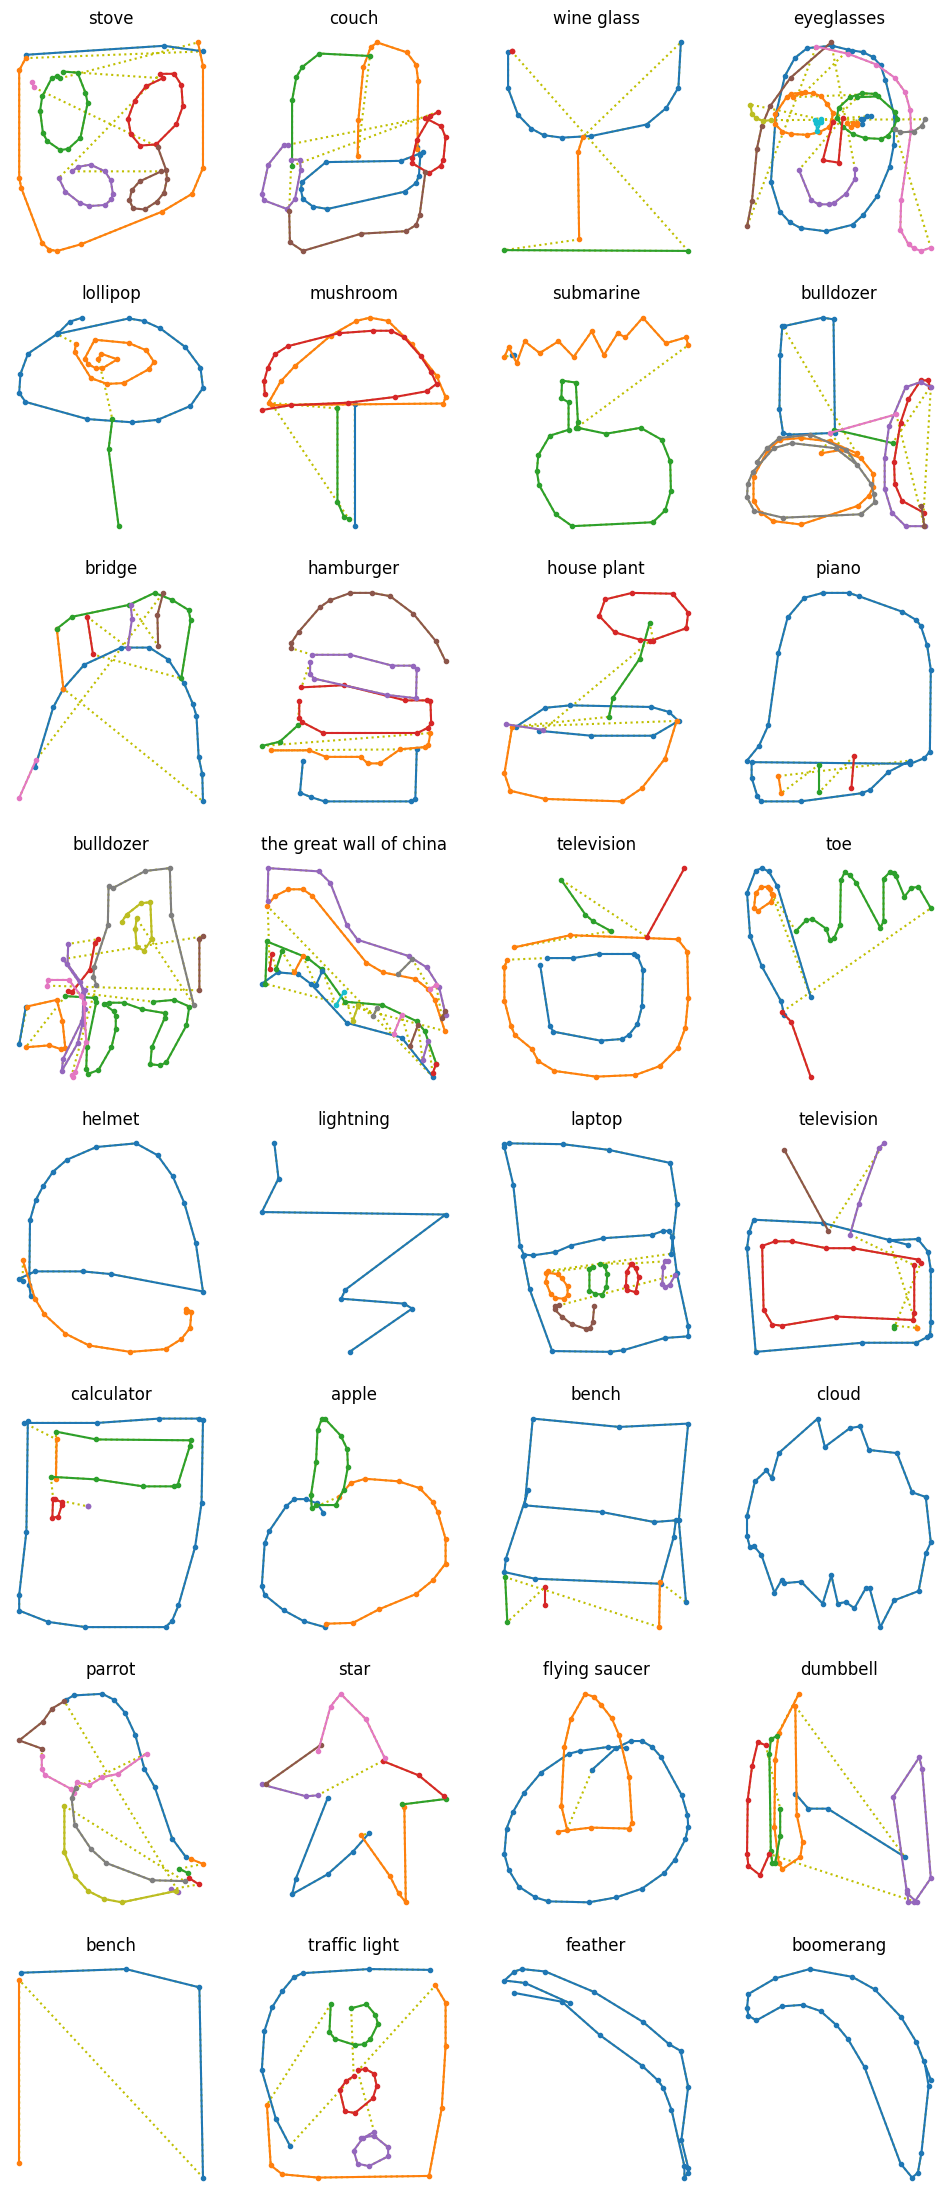

In [90]:
def draw_sketch(sketch, label=None):
    origin = np.array([[0., 0., 0.]])
    sketch = np.r_[origin, sketch]
    stroke_end_indices = np.argwhere(sketch[:, -1]==1.)[:, 0]
    coordinates = np.cumsum(sketch[:, :2], axis=0)
    strokes = np.split(coordinates, stroke_end_indices + 1)
    title = class_names[label.numpy()] if label is not None else "Try to guess"
    plt.title(title)
    plt.plot(coordinates[:, 0], -coordinates[:, 1], "y:")
    for stroke in strokes:
        plt.plot(stroke[:, 0], -stroke[:, 1], ".-")
    plt.axis("off")

def draw_sketches(sketches, lengths, labels):
    n_sketches = len(sketches)
    n_cols = 4
    n_rows = (n_sketches - 1) // n_cols + 1
    plt.figure(figsize=(n_cols * 3, n_rows * 3.5))
    for index, sketch, length, label in zip(range(n_sketches), sketches, lengths, labels):
        plt.subplot(n_rows, n_cols, index + 1)
        draw_sketch(sketch[:length], label)
    plt.show()

for sketches, lengths, labels in train_set.take(1):
    draw_sketches(sketches, lengths, labels)

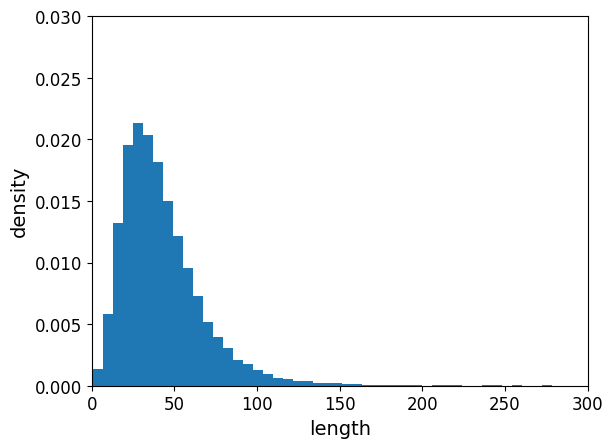

In [91]:
lengths=np.concatenate([lengths for _ ,lengths, _ in train_set.take(1000)])
plt.hist(lengths, bins=150,density=True)
plt.axis([0, 300, 0, 0.03])
plt.xlabel("length")
plt.ylabel("density")
plt.show()

In [93]:
def crop_long_sketches(dataset,max_length=100):
  return dataset.map(lambda inks ,lengths,labels:(inks[:,:max_length],labels))

cropped_train_set=crop_long_sketches(train_set)
cropped_valid_set=crop_long_sketches(valid_set)
cropped_test_set=crop_long_sketches(test_set)

In [97]:

model = keras.models.Sequential([
    keras.layers.Conv1D(32, kernel_size=5, strides=2, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv1D(64, kernel_size=5, strides=2, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv1D(128, kernel_size=3, strides=2, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.LSTM(128, return_sequences=True),
    keras.layers.LSTM(128),
    keras.layers.Dense(len(class_names), activation="softmax")
])
optimizer = keras.optimizers.SGD(learning_rate=1e-2, clipnorm=1.)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy", "sparse_top_k_categorical_accuracy"])
history = model.fit(cropped_train_set, epochs=4,
                    validation_data=cropped_valid_set)

Epoch 1/4
 107813/Unknown 1097s 10ms/step - accuracy: 0.0754 - loss: 4.8905 - sparse_top_k_categorical_accuracy: 0.1955

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


107813/107813 ━━━━━━━━━━━━━━━━━━━━ 1125s 10ms/step - accuracy: 0.1623 - loss: 4.1360 - sparse_top_k_categorical_accuracy: 0.3615 - val_accuracy: 0.2965 - val_loss: 3.1527 - val_sparse_top_k_categorical_accuracy: 0.5783
Epoch 2/4
107813/107813 ━━━━━━━━━━━━━━━━━━━━ 1162s 10ms/step - accuracy: 0.3757 - loss: 2.7231 - sparse_top_k_categorical_accuracy: 0.6653 - val_accuracy: 0.4238 - val_loss: 2.4676 - val_sparse_top_k_categorical_accuracy: 0.7128
Epoch 3/4
107813/107813 ━━━━━━━━━━━━━━━━━━━━ 1113s 10ms/step - accuracy: 0.4504 - loss: 2.3314 - sparse_top_k_categorical_accuracy: 0.7371 - val_accuracy: 0.4742 - val_loss: 2.2169 - val_sparse_top_k_categorical_accuracy: 0.7574
Epoch 4/4
107813/107813 ━━━━━━━━━━━━━━━━━━━━ 1113s 10ms/step - accuracy: 0.4918 - loss: 2.1264 - sparse_top_k_categorical_accuracy: 0.7719 - val_accuracy: 0.4990 - val_loss: 2.0834 - val_sparse_top_k_categorical_accuracy: 0.7793


In [98]:
y_test=np.concatenate([labels for _, _, labels in test_set])
y_probas=model.predict(test_set)

5392/5392 ━━━━━━━━━━━━━━━━━━━━ 36s 7ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [99]:
np.mean(keras.metrics.sparse_top_k_categorical_accuracy(y_test,y_probas))

np.float32(0.64789486)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step


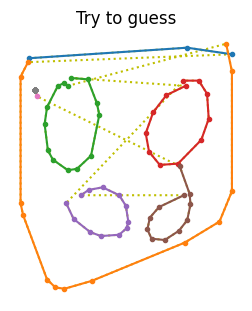

Top-5 predictions:
  1. stove 72.389%
  2. stereo 8.950%
  3. pizza 4.306%
  4. peas 4.105%
  5. radio 1.383%
Answer: stove


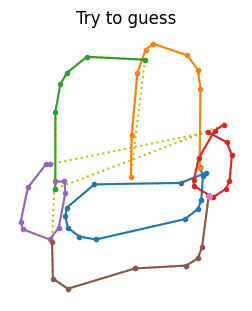

Top-5 predictions:
  1. couch 20.814%
  2. hat 11.627%
  3. toilet 9.174%
  4. flying saucer 6.514%
  5. rollerskates 4.985%
Answer: couch


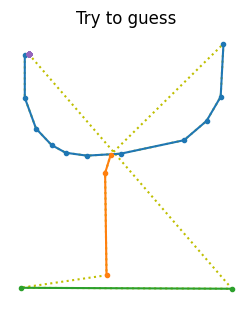

Top-5 predictions:
  1. wine glass 57.036%
  2. smiley face 9.996%
  3. fork 4.482%
  4. necklace 4.252%
  5. canoe 3.852%
Answer: wine glass


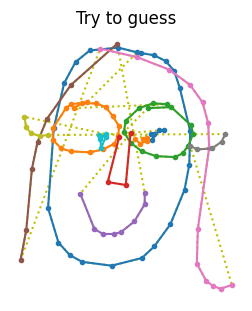

Top-5 predictions:
  1. face 35.349%
  2. owl 28.415%
  3. the mona lisa 11.048%
  4. smiley face 4.143%
  5. beard 3.866%
Answer: eyeglasses


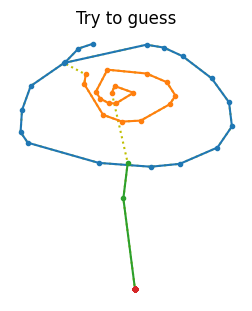

Top-5 predictions:
  1. lollipop 98.239%
  2. flying saucer 0.564%
  3. spoon 0.263%
  4. stop sign 0.130%
  5. flower 0.065%
Answer: lollipop


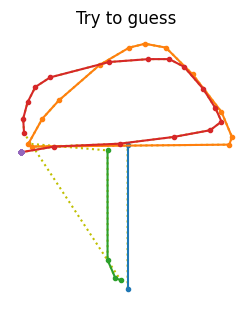

Top-5 predictions:
  1. ice cream 63.094%
  2. lollipop 14.458%
  3. mushroom 11.509%
  4. tree 1.704%
  5. umbrella 1.411%
Answer: mushroom


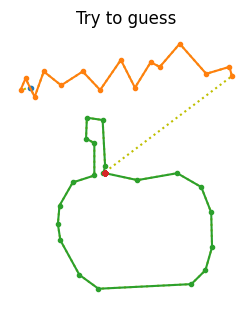

Top-5 predictions:
  1. submarine 36.542%
  2. blueberry 11.642%
  3. mouth 6.210%
  4. pond 4.250%
  5. pineapple 4.155%
Answer: submarine


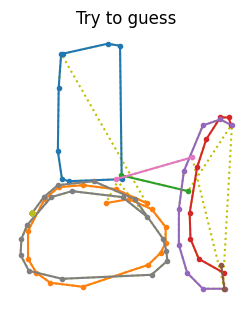

Top-5 predictions:
  1. grapes 23.129%
  2. bulldozer 12.713%
  3. ceiling fan 7.973%
  4. tractor 5.012%
  5. toilet 4.877%
Answer: bulldozer


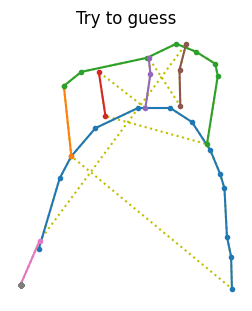

Top-5 predictions:
  1. church 15.563%
  2. toaster 15.215%
  3. bridge 6.510%
  4. finger 6.481%
  5. nail 5.160%
Answer: bridge


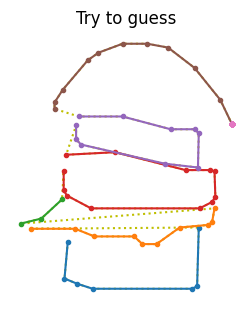

Top-5 predictions:
  1. hamburger 93.898%
  2. snowman 0.938%
  3. floor lamp 0.900%
  4. toilet 0.721%
  5. sandwich 0.662%
Answer: hamburger


In [100]:
n_new=10
Y_probas=model.predict(sketches)
top_k=tf.nn.top_k(Y_probas,k=5)
for index in range(n_new):
  plt.figure(figsize=(3,3.5))
  draw_sketch(sketches[index])
  plt.show()
  print("Top-5 predictions:".format(index+1))
  for k in range(5):
    class_name=class_names[top_k.indices[index,k]]
    proba=100*top_k.values[index,k]
    print("  {}. {} {:.3f}%".format(k + 1, class_name, proba))
  print("Answer: {}".format(class_names[labels[index].numpy()]))


In [111]:
model.save("SketchRNN.keras")